In [3]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date
import statsmodels.api as sm
from statsmodels.stats.weightstats import ztest as ztest
from sklearn.metrics import r2_score as R2S
import cairo

#from lmfit import Model

In [4]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2024-01-26


'2024-01-26'

In [5]:
tubulin = '[Tubulin] (' r'$\mu$' 'M)'
tub = 'tub'

DCXconc = '[DCX] (nM)' 
EBconc = '[EB] (nM)'
DCX = 'DCX'
Type = 'DCX Type'

Concentration = 'Concentration (' r'$\mu$' 'M)'
Length = 'Length (' r'$\mu$' 'm)'
Lifetime = 'Lifetime (min)'
GrowthRate = 'Growth Rate (' r'$\mu$' 'm/min)'
TimeToNucleate = 'Time to Nucleate (min)'
ShrinkageLength = 'Shrink Length (' r'$\mu$' 'm)'
ShrinkageLifetime = 'Shrink Lifetime (min)'
ShrinkageRate = 'Shrink Rate (' r'$\mu$' 'm/min)'
RescuePerLength = 'Rescues (' r'$\mu$' 'm' r'$^{-1}$' ')'

In [6]:
Type_order = ['None', 'Y64N','R76S','R102S', 'R178L', 'P191R', 'G223E','R303X', 'WT']

category_Type = CategoricalDtype(Type_order, ordered=True,) #order mutants

In [40]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
yellow = '#FFCB05'
lightyellow = '#F9DC2D'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))
print(DC1color,DC2color)

DC1palette = list(map(Color.get_hex,DC1color))

palette_all = [grey] + [DC1palette[0]] + [DC1palette[1]] + list(map(Color.get_hex,DC2color)) + [cyan]

parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

[<Color #ab4a9c>, <Color #e468b8>, <Color #ffa4cd>] [<Color #ff5b00>, <Color #ff8341>, <Color #ffac83>]


In [8]:
### font for matplotlib
matplotlib.rcParams['font.family'] = 'Helvetica Neue LT Std'

#  Open saved fit parameters  #

In [9]:
askFitParam = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
ResultFit = pd.read_csv(askFitParam, encoding='utf-8')
ResultFit[Type] = ResultFit[Type].fillna('None')
ResultFit

,Fit,SE,Coefficient,[Tubulin] ($\mu$M),DCX Type,[DCX] (nM),Parameter,Moment
0,1.070577,0.008903,0.0,12,None,0,Growth Rate ($\mu$m/min),Mean
1,0.157043,0.007290,1.0,12,None,0,Growth Rate ($\mu$m/min),Std
2,0.797346,0.025314,0.0,8,None,0,Growth Rate ($\mu$m/min),Mean
3,0.149149,0.020669,1.0,8,None,0,Growth Rate ($\mu$m/min),Std
4,0.416686,0.002427,0.0,6,None,0,Growth Rate ($\mu$m/min),Mean
...,...,...,...,...,...,...,...,...
363,5.080860,0.468668,1.0,14,None,0,Shrink Rate ($\mu$m/min),Std
364,19.051355,0.549069,0.0,10,None,0,Shrink Rate ($\mu$m/min),Mean
365,5.591572,0.456008,1.0,10,None,0,Shrink Rate ($\mu$m/min),Std
366,12.426828,0.919834,0.0,7,None,0,Shrink Rate ($\mu$m/min),Mean


In [32]:
ResultFit = ResultFit[(ResultFit['DCX Type'] != 'R303X') & (ResultFit['DCX Type'] != 'R102S')]
ResultFit['DCX Type'].unique()

array(['None', 'Y64N', 'R76S', 'R178L', 'P191R', 'G223E', 'WT'],
      dtype=object)

In [188]:
resultdirectory = str(Path(askFitParam).parent)+'//Plots_'+date
newmydir = Path(resultdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('C:/Users/sofia/OneDrive - McGill University/EJCB2023/Sofia_EJCB_Figs/Data/2023-08-08_fitdata-final/Plots_2024-01-26')

## dcx EQ FIT ##

In [11]:
def pickdata(dcxtype, parameterNo):
    dcxtype_DF = ResultFit[(ResultFit[Type]==dcxtype) & (ResultFit['Moment']=='Mean')& (ResultFit[tubulin]==6)]

    parameterMeanDF = dcxtype_DF[dcxtype_DF['Parameter']==parameters[parameterNo]]

    x = parameterMeanDF[DCXconc].values
    y = parameterMeanDF['Fit'].values
    yerr = parameterMeanDF['SE'].values
    
    return x,y,yerr

In [12]:
def hillEQ(x, n, kd, Y):
    return  (YL[-1]- Y[0]) * np.power(x, n)/(kd + np.power(x, n)) + Y[0]

In [13]:
def reduced_chi_squared(obs,fit,sigma,freedom): 

    return np.sum(np.square(fit - obs)/np.square(sigma)) / freedom

In [14]:
x,y,yerr = pickdata('WT', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = [*x0,*x]
YL = [*y0,*y]
YerrL = [*yerr0,*yerr]

logx = np.log(X[1:-1])
normyL =( YL[1:-1]-YL[0])/(YL[-1]-YL[0])
logyL = np.log(normyL/(1-normyL))

p, cov = np.polyfit(logx, logyL, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

mL,bL = p


p, SElin

(array([  3.24769793, -13.0913579 ]), array([0.5427463 , 2.26854382]))

In [15]:
linfitYL = np.multiply(logx,mL) + bL

In [16]:
R2S(logyL,logx*mL+bL)

0.947098541668598

In [17]:

fitYL = hillEQ(X,p[0], np.exp(-p[1]),YL)
fitYL

array([ 3.84602165,  5.07852635,  8.41376882, 10.56691598, 11.98210304,
       12.70987654])

In [18]:
v = len(YL) - 2

In [19]:
reduced_chi_squared(YL,fitYL,YerrL,v)

0.046920562085981415

In [72]:
def hill_plot_fitMUT(dcxtype):
    x,y,yerr = pickdata(dcxtype, 2)
    x0,y0,yerr0 = pickdata('None', 2)

    X = np.array(x)
    YLmut = np.array(y)
    YerrLmut = yerr

    logxmut = np.log(X[1:])
    normyL =( YLmut[1:]-YLmut[0])/(YL[-1]-YLmut[0])
    logyLmut = np.log(normyL/(1-normyL))

    pmut, cov = np.polyfit(logxmut, logyLmut, 1, cov=True)
    var = np.diagonal(cov) #Refer [3]
    SElinmut = np.sqrt(var) #Refer [4]

    return    pmut, SElinmut


In [82]:
x,y,yerr = pickdata('R76S', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = np.array(x)
YL76 = np.array(y)
YerrL76 = yerr

p76 , SE76 = hill_plot_fitMUT('R76S')
p76 , SE76

(array([  3.22323167, -17.71173874]), array([1.08894694, 5.08725883]))

In [76]:
fitYL76 = hillEQ(X,p76[0], np.exp(-p76[1]),YL76)
fitYL76

array([3.46563959, 3.5381493 , 3.69424532, 4.19801844, 7.60299689])

In [77]:
reduced_chi_squared(YL76,fitYL76,YerrL76,v)

1.2224861527628934

In [88]:
#K_A76
np.exp(-p76[1]/p76[0])

243.47762499225308

In [83]:
x,y,yerr = pickdata('P191R', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = np.array(x)
YL191 = np.array(y)
YerrL191 = yerr

p191 , SE191 = hill_plot_fitMUT('P191R')
p191 , SE191

(array([  2.50104811, -14.14968789]), array([0.3204507 , 1.49705701]))

In [84]:
fitYL191 = hillEQ(X,p191[0], np.exp(-p191[1]),YL191)
fitYL191

array([2.98682482, 3.11682823, 3.32422615, 3.84095945, 6.48124947])

In [85]:
reduced_chi_squared(YL191,fitYL191,YerrL191,v)

0.05548011489598395

In [90]:
def K_A(p):
    return np.exp(-p[1]/p[0]) , np.exp(-p[1]/p[0])/p[0]*np.sqrt(np.square(SElin[1])+np.square(p[1]*SElin[0]/p[0]))

In [93]:
K_A(p)

(56.31525016671599, 54.64929293593946)

In [91]:
K_A(p76)

(243.47762499225308, 283.05249199530596)

In [92]:
K_A(p191)

(286.43260895654004, 437.2218206763217)

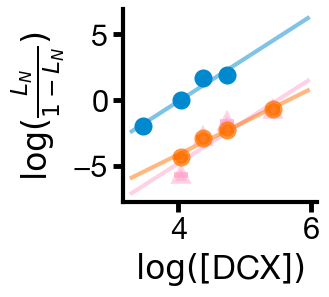

In [71]:
scattersize = 9
cap = 5

fig, ax = plt.subplots(1,1,figsize=(2.5,2.5))
ax.errorbar(logx , logyL , yerr= 0 , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color=cyan, alpha = 1, ls='')
ax.errorbar(logx76 , logyL76 , yerr= 0 , fmt='',marker='^', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color=pink, alpha = 0.5, ls='')
ax.errorbar(logx191 , logyL191 , yerr= 0 , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color=orange, alpha = 0.75, ls='')


x0 = np.arange(3.3, 6, 0.05)

ax.plot(x0, x0*mL+bL,color = cyan, lw=3,ls= '-',alpha = 0.5)
ax.plot(x0, x0*mL76+bL76,color = pink, lw=3,ls= '-',alpha = 0.5)
ax.plot(x0, x0*mL191+bL191,color = orange, lw=3,ls= '-',alpha = 0.5)
# ax.set_ylim(-2.5,2.5)
# ax.set_xlim(3,5)
ax.set_xlabel(r'$\log([$''DCX' r'$])$')
#ax.set_xticks(np.arange(0, 22.1, 2))
#ax.set_yticks(np.arange(0, 150.1, 25))
ax.set_ylabel(r'$\log(\frac{L_N}{1-L_N})$') 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)

#ax.legend((r'$n=2.94 \pm 0.49$' '\n' r'$R^2 > 0.945$',),loc='lower right',title='Hill Equation')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

#plt.savefig(newmydir/('logexpHillfit_Lifetime_'+date+'.pdf'), bbox_inches = 'tight')

In [26]:
def pickdata(dcxtype, parameterNo):
    dcxtype_DF = ResultFit[(ResultFit[Type]==dcxtype) & (ResultFit['Moment']=='Mean')& (ResultFit[tubulin]==6)]

    parameterMeanDF = dcxtype_DF[dcxtype_DF['Parameter']==parameters[parameterNo]]

    x = parameterMeanDF[DCXconc].values
    y = parameterMeanDF['Fit'].values
    yerr = parameterMeanDF['SE'].values
    
    return x,y,yerr

In [43]:
ResultFit[Type].unique()[1:-1]

array(['Y64N', 'R76S', 'R178L', 'P191R', 'G223E'], dtype=object)

In [72]:
def reduced_chi_squared(obs,fit,sigma,freedom): 

    return np.sum(np.square(fit - obs)/np.square(sigma)) / freedom

In [96]:
def lin_fit(dcxtype):
    x,y,yerr = pickdata(dcxtype, 2)
    x0,y0,yerr0 = pickdata('None', 2)
    
    X = [*x0,*x]
    Y = [*y0,*y]
    Yerr = [*yerr0,*yerr]
    
    p, cov = np.polyfit(X,Y, 1, cov=True)
    var = np.diagonal(cov) #Refer [3]
    SElin = np.sqrt(var) #Refer [4]

    fitY = np.multiply(X,p[0])+p[1]
    
    R = R2S(Y,fitY)

    chi = reduced_chi_squared(Y,fitY,Yerr,len(Y)-2)
    
    return p, SElin, R, chi

In [168]:

lin_fit_results = pd.DataFrame(columns=[] , index=[])

for dcxtype in ResultFit[Type].unique()[1:-1]:#ResultFit[Type].unique(): #data[Type].unique(): #['None','R76S','P191R','WT']
    
    p , SElin, R, chi = lin_fit(dcxtype)

    results0 = {'DCX Type': [dcxtype], 'Slope': [p[0]], 'Slope SD': [SElin[0]], 'Intercept': [p[1]], 'Intercept SD': [SElin[1]], 'R^2': [R], 'chi^2': [chi]}

    lin_fit_results = pd.concat([lin_fit_results, pd.DataFrame(results0)], sort=False)



In [169]:
x,y,yerr = pickdata('WT', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = [*x0,*x][:-2]
Y = [*y0,*y][:-2]
Yerr = [*yerr0,*yerr][:-2]

p, cov = np.polyfit(X,Y, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

fitY = np.multiply(X,p[0])+p[1]

R = R2S(Y,fitY)

chi = reduced_chi_squared(Y,fitY,Yerr,len(Y)-2)

results0 = {'DCX Type': ['WT'], 'Slope': [p[0]], 'Slope SD': [SElin[0]], 'Intercept': [p[1]], 'Intercept SD': [SElin[1]], 'R^2': [R], 'chi^2': [chi]}
lin_fit_results = pd.concat([lin_fit_results, pd.DataFrame(results0)], sort=False)

lin_fit_results['Relative Slope'] = lin_fit_results['Slope']/p[0]
lin_fit_results['Relative Slope SD'] = lin_fit_results['Slope']/p[0] * np.sqrt(np.square(SElin[0]/p[0])+np.square(lin_fit_results['Slope SD']/lin_fit_results['Slope']))

lin_fit_results

,DCX Type,Slope,Slope SD,Intercept,Intercept SD,R^2,chi^2,Relative Slope,Relative Slope SD
0,Y64N,0.018012,0.002228,3.600759,0.249191,0.942316,0.356564,0.185343,0.043832
0,R76S,0.013165,0.002512,3.221384,0.280964,0.872855,0.989819,0.135472,0.037602
0,R178L,0.006940,0.002711,4.106672,0.303143,0.621059,0.785782,0.071417,0.031388
0,P191R,0.013090,0.003930,2.802088,0.439475,0.735017,1.493460,0.134694,0.048705
0,G223E,0.016325,0.003312,3.456260,0.370437,0.858596,0.625609,0.167978,0.048042
0,WT,0.097182,0.019588,3.048216,1.004230,0.924857,1.892946,1.000000,0.285041


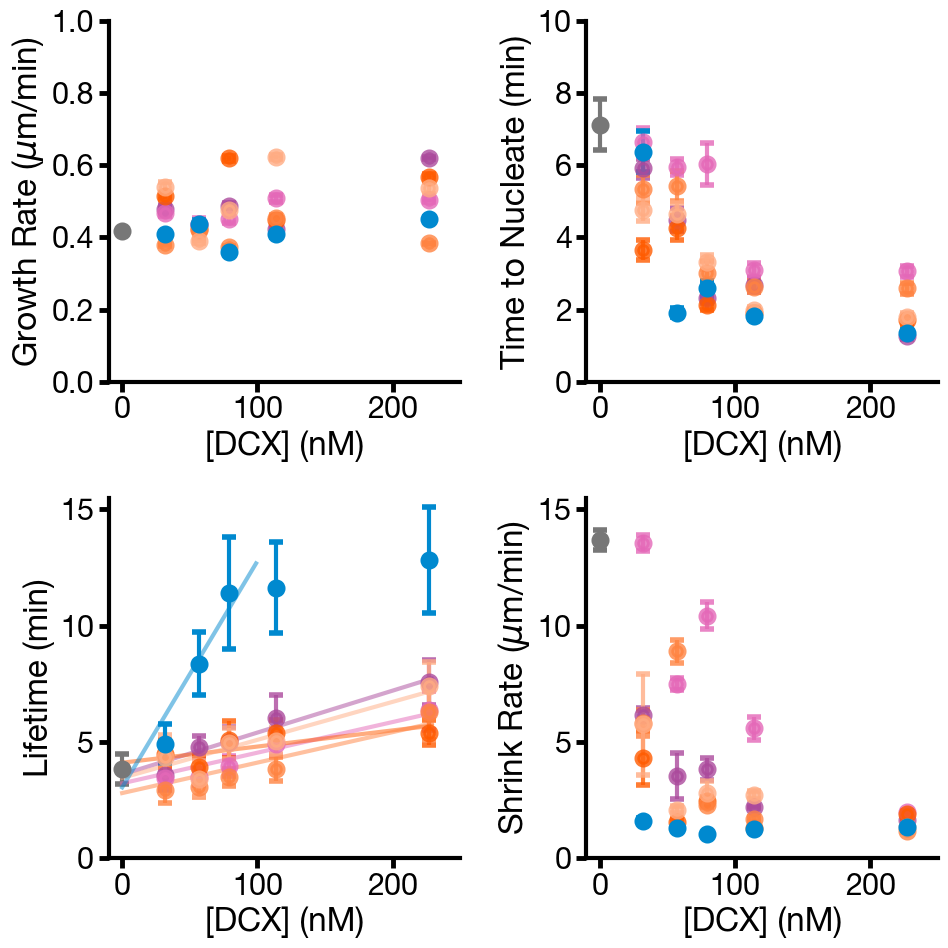

In [115]:
scattersize = 9
cap = 5

parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]
titles = ('Growth','Nucleation','Lifetime','Shrinkage Rate')
ylables = (GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate)

fig, ax = plt.subplots(2,2,figsize=(10,10))

linx = np.arange(0, 230, 1)

# ax[0][0].plot(linx, linx*mG+bG ,color = cyan, lw=3,ls= '-',alpha = 0.5,label='_nolegend_')





count = 0

palette = palette_all
#palette = [grey,list(map(Color.get_hex,DC1color))[1],list(map(Color.get_hex,DC2color))[1],cyan] #+ list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green,cyan]
#palette = [grey,cyan]

for dcxtype in ResultFit[Type].unique():#ResultFit[Type].unique(): #data[Type].unique(): #['None','R76S','P191R','WT']
    
    dcxtype_DF = ResultFit[(ResultFit[Type]==dcxtype) & (ResultFit['Moment']=='Mean')& (ResultFit[tubulin]==6)]

    
    
    c=0
    for i in np.arange(len(ax)):
        for j in np.arange(len(ax)):
    
            parameterMeanDF = dcxtype_DF[dcxtype_DF['Parameter']==parameters[c]]

            x = parameterMeanDF[DCXconc].values
            y = parameterMeanDF['Fit'].values
            yerr = parameterMeanDF['SE'].values
            
            if dcxtype == 'None' or  dcxtype == 'WT':

                ax[i][j].errorbar(x , y , yerr= yerr , fmt=' ',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3,color=palette[count], alpha = 1)
            
            else:
                ax[i][j].errorbar(x , y , yerr= yerr , fmt=' ',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3,color=palette[count], alpha = 0.80)

            c += 1

    count += 1


count = 1
for dcxtype in ResultFit[Type].unique()[1:-1]:
    
    fitparams = lin_fit_results[lin_fit_results['DCX Type']==dcxtype]
    p = fitparams['Slope'].values
    b = fitparams['Intercept'].values
    ax[1][0].plot(linx, linx*p+b ,color = palette_all[count], lw=3,ls= '-',alpha = 0.5,label='_nolegend_')

    count += 1

fitparams = lin_fit_results[lin_fit_results['DCX Type']=='WT']
p = fitparams['Slope'].values
b = fitparams['Intercept'].values
ax[1][0].plot(linx[linx < 100], linx[linx < 100]*p+b ,color = palette_all[-1], lw=3,ls= '-',alpha = 0.5,label='_nolegend_')

ax[0][0].set_ylim(0,1)
ax[1][0].set_ylim(0,15.5)
ax[0][1].set_ylim(0,10)
ax[1][1].set_ylim(0,15.5)


# linx = np.arange(30, 230, 1)
# ax[1][1].plot(linx, linx*mS+bS,color = cyan, lw=3,ls= '-',alpha = 0.5)

count = 0
for i in np.arange(len(ax)):
    for j in np.arange(len(ax)):
    
          
        ax[i][j].set_xlim(-10,250)
        ax[i][j].set_xlabel(DCXconc)
        ax[i][j].set_xticks(np.arange(0, 251, 100))
        ax[i][j].set_ylabel(ylables[count])
        ax[i][j].spines['right'].set_visible(False)
        ax[i][j].spines['top'].set_visible(False)
        ax[i][j].spines['left'].set_lw(3)
        ax[i][j].spines['bottom'].set_lw(3)
        ax[i][j].tick_params(axis='both', width = 3.5, length = 7)
        #ax[i][1].legend((Type_order),loc='upper right',title='DCX Type')
        #ax[i][j].set_title(titles[count])
        ax[i][j].margins(2)
        count += 1

#ax[0][0].legend((Type_order),loc='upper right',title='DCX Type')
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()

plt.savefig(newmydir/('lifetime_linfit__all-mutants'+date+'.pdf'))

In [99]:
newmydir

WindowsPath('C:/Users/sofia/OneDrive - McGill University/EJCB2023/Sofia_EJCB_Figs/Data/2023-08-08_fitdata-final')

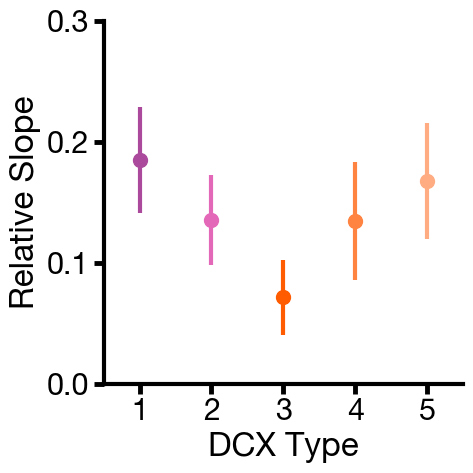

In [190]:
fig, ax = plt.subplots(1,1,figsize=(5.25,5.25))

count = 1
for dcxtype in ResultFit[Type].unique()[1:-1]:

    
    fitparams = lin_fit_results[lin_fit_results['DCX Type']==dcxtype]
    p = fitparams['Relative Slope'].values
    psd = fitparams['Relative Slope SD'].values
    b = fitparams['Intercept'].values
    bsd = fitparams['Intercept SD'].values


    ax.errorbar([count], p, yerr=psd, color = palette_all[count],marker = 'o',markersize = 10)
    #sns.catplot(data= )

    count += 1

ax.set_ylabel('Relative Slope')
ax.set_xlabel('DCX Type')

ax.set_xlim(0.5,5.5)
ax.set_xticks(np.arange(1, 5.1,1))
ax.set_ylim(0,0.3)
ax.set_yticks(np.arange(0, 0.31,0.1))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(newmydir/('relative_slope_'+date+'.pdf'))



In [175]:
p

array([0.18534301])